### Imports and data loading from .csv file

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sn  #Per heatmap
import time
import scipy as sp
import os
import librosa as lb
from random import randrange

#sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder,OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, ParameterGrid, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
data = pd.read_csv('../data/development.csv', index_col=0)
data['path'] = data['path'].map(lambda x: x.split('/')[1])
display(data)

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893,1.wav
1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662,2.wav
2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998,3.wav
3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127,4.wav
4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905,5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,[184.5703125],-100.921055,69,281,11,17.461406,2929.wav
2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,[83.35433468],6.757283,0,0,1,1.509206,2930.wav
2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,[89.10290948],-53.913449,1,9,1,1.645034,2931.wav


### Ethnicity subgroups identification

In [3]:
sentence_feat = data.loc[:,['num_words','num_characters']].values
uniq, ind, count= np.unique(np.array(sentence_feat), return_counts=True, return_inverse=True, axis=0)
display(count)
print(uniq[-1])

array([ 409,    2,    1,   39,    8,    5,    2,    3,    3,    3,    1,
          8,    5,   19,    9,   16,    7,    7,    1,    4,    1,    2,
          9,    8,   27,   66,   26,    6,    5,    7,    2,   58,    1,
         52,   56,    6,   51,    5,    9,    4,    8,    4,    1,    2,
          3,    3,   15,    1,    6,    2,   28,    3,   55,   28,    3,
          1,   44,    1,    1,    5,    4,    5,    1,    1,    1,    2,
          6,    3,   11,   16,    1,    1,    1,    1,    1,    1, 1710])

[ 69 281]


In [4]:
data.loc[ind==76,'ethnicity'] = 1
data.loc[ind!=76,'ethnicity'] = 0
clean_data = data.drop(columns=['num_words','num_characters','num_pauses','sampling_rate','max_pitch','min_pitch'])
clean_data['tempo'] = clean_data['tempo'].map(lambda x: float(x[1:-1]))
clean_data['gender'] = clean_data['gender'].map(lambda x: 1 if x=='male' else 0)
display(clean_data)

,age,gender,ethnicity,mean_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,silence_duration,path
Id,,,,,,,,,,,,,
0,24.0,0,1,1821.69060,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,23.846893,1.wav
1,22.5,0,1,1297.81870,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,19.388662,2.wav
2,22.0,0,1,1332.85240,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,21.640998,3.wav
3,22.0,0,1,1430.34990,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,19.644127,4.wav
4,22.0,1,1,1688.72340,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,18.041905,5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,24.0,1,1,1641.14930,0.023647,0.115361,0.001879,0.111799,2188.853478,184.570312,-100.921055,17.461406,2929.wav
2929,15.0,0,0,1089.60050,0.015317,0.126740,0.000339,0.070508,2712.362323,83.354335,6.757283,1.509206,2930.wav
2930,17.0,0,0,994.46484,0.009677,0.103535,0.001464,0.058442,2248.698477,89.102909,-53.913449,1.645034,2931.wav


In [5]:
data_long = clean_data[clean_data['ethnicity']==1].drop(columns=['ethnicity'])
data_short = clean_data[clean_data['ethnicity']==0].drop(columns=['ethnicity'])

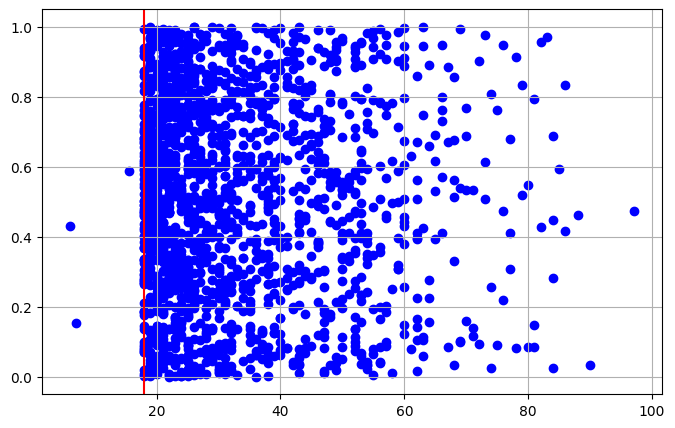

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(data_long['age'],np.random.uniform(0,1,data_long.shape[0]), color='blue', label='Long-form')
plt.axvline(18, color='red', label='Age cut-off')
plt.grid()
plt.show()

In [7]:
RANDOM_SEED = 42
SAMPLE_RATE = 22050

In [8]:
data_long_train, data_long_val = train_test_split(data_long, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)

In [9]:
display(data_long_val)

,age,gender,mean_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,silence_duration,path
Id,,,,,,,,,,,,
1945,43.0,1,1350.5623,0.025365,0.088283,0.011530,0.099948,1832.121702,129.199219,-65.708777,23.405714,1946.wav
2809,24.0,0,1752.6995,0.020853,0.099716,0.002544,0.186948,2733.518540,112.347147,-101.617870,16.044989,2810.wav
2739,50.0,1,1311.5924,0.031923,0.132028,0.011493,0.116655,1828.541426,123.046875,-81.173533,22.593016,2740.wav
187,27.0,0,1111.5004,0.029676,0.120268,0.003481,0.075599,1718.927567,135.999178,-107.707566,17.182766,188.wav
1969,21.0,1,1808.4218,0.019482,0.111949,0.002330,0.196146,2885.572997,129.199219,-94.411806,16.741587,1970.wav
...,...,...,...,...,...,...,...,...,...,...,...,...
1163,37.0,0,1063.7135,0.028573,0.112565,0.003962,0.135288,2490.809893,129.199219,-84.959156,15.880045,1164.wav
2563,57.0,1,1332.0780,0.013829,0.095649,0.000622,0.253630,3777.080758,151.999081,-143.711687,29.860862,2564.wav
1902,19.0,1,1736.8174,0.018249,0.137243,0.002969,0.216647,3395.470897,135.999178,-83.721809,16.044989,1903.wav


In [10]:
display(data_long_train)

,age,gender,mean_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,silence_duration,path
Id,,,,,,,,,,,,
1438,35.0,1,1646.9224,0.029147,0.098140,0.010600,0.114074,2166.855143,103.359375,-61.277650,18.134785,1439.wav
1002,24.0,1,1609.1211,0.017003,0.129609,0.002806,0.177686,2747.243990,135.999178,-109.322569,18.738503,1003.wav
1505,48.0,0,930.8177,0.020077,0.101774,0.006230,0.070463,1447.012538,184.570312,-94.565697,30.627120,1506.wav
2688,29.0,1,1916.5143,0.025554,0.115902,0.006831,0.158789,2710.914328,129.199219,-67.567210,16.114649,2689.wav
734,20.0,1,804.3894,0.022372,0.174446,0.005474,0.107776,1823.592869,135.999178,-83.051619,24.984671,735.wav
...,...,...,...,...,...,...,...,...,...,...,...,...
1935,19.0,1,1550.9205,0.014337,0.111289,0.002682,0.247303,3251.795287,123.046875,-118.451541,24.706032,1936.wav
2217,44.0,1,1273.4888,0.026688,0.113353,0.009831,0.071949,2003.992060,117.453835,-83.390905,31.856961,2218.wav
1480,23.0,0,1559.6954,0.016365,0.071521,0.006539,0.104753,1573.181832,103.359375,-91.918861,20.549660,1481.wav


## Data extraction - Functions

In [11]:
def silence_removal(audio_array, threshold=60, ref=np.max, aggregate=np.max):
    # Compute the MSE for the signal
    #mse = lb.feature.rms(y=audio_array, frame_length=1, hop_length=1)
    # Convert to decibels and slice out the mse channel
    db = lb.core.amplitude_to_db(audio_array, ref=ref, top_db=None)
    # Aggregate everything but the time dimension
    if db.ndim > 1:
        db = np.apply_over_axes(aggregate, db, range(db.ndim - 1))
        # Squeeze out leading singleton dimensions here
        # We always want to keep the trailing dimension though
        db = np.squeeze(db, axis=tuple(range(db.ndim - 1)))
    nonzero = np.flatnonzero(db > -threshold)
    return audio_array[nonzero]

In [12]:
def load_data(audio_files, folder_path, sample_rate,silence_threshold=60):
    time_stamps = []
    audio_arrays = {}
    for file_name in audio_files:
        if file_name.endswith(".wav"):
            audio_array = lb.load(folder_path + file_name)
            trimmed_audio_array= lb.effects.trim(audio_array[0])
            noSilence = silence_removal(trimmed_audio_array[0], threshold=silence_threshold, ref=np.max(trimmed_audio_array[0]), aggregate=np.max(trimmed_audio_array[0]))
            time_stamps.append(len(noSilence))
            audio_arrays[file_name] = noSilence            
    return (audio_arrays, np.array(time_stamps))

In [13]:
def standardize_time_mfcc(mfcc,num_buckets):
    reduced_list =[]
    existing_int = mfcc.shape[1]
    for i in range(0,existing_int-(existing_int%num_buckets),existing_int//num_buckets):
        reduced_list.append(np.mean(mfcc[:, i:i+(mfcc.shape[1]//num_buckets)], axis=1).flatten())
    return np.array(reduced_list).transpose()

In [14]:
def standardize_all(mfcc_dict,num_buckets):
    standard_mfccs = {}
    for name, mfcc in mfcc_dict.items():
        standard_mfccs[name] = standardize_time_mfcc(mfcc,num_buckets)
    return standard_mfccs

In [15]:
def reshape_all(mfcc_dict):
    reshaped_mfccs = {}
    for name, mfcc in mfcc_dict.items():
        reshaped_mfccs[name] = mfcc.flatten()
    return pd.DataFrame(reshaped_mfccs).T

In [16]:
def flatten_all(mfcc_dict):
    flattened_mfccs = {}
    for name, mfcc in mfcc_dict.items():
        flattened_mfccs[name] = mfcc.mean(axis=1).flatten()
    return pd.DataFrame(flattened_mfccs).T

In [17]:
def random_crop(mfcc_dict,crop_dim):
    random_mfccs = {}
    for name, mfcc in mfcc_dict.items():
        start = randrange(mfcc.shape[1]-crop_dim+1)
        random_mfccs[name] = mfcc[:, start:start+crop_dim]
    return random_mfccs

In [18]:
def random_crop_byAge(mfcc_dict,crop_dim, data, max_age, min_age):
    random_mfccs = {}
    for name, mfcc in mfcc_dict.items():
        start = randrange(mfcc.shape[1]-crop_dim+1)
        random_mfccs[name] = mfcc[:, start:start+crop_dim]
        if (data.loc[data['path'] == name, 'age']>max_age or data.loc[data['path'] == name, 'age']<min_age):
            start = randrange(mfcc.shape[1]-crop_dim+1)
            random_mfccs[name+'(age)'] = mfcc[:, start:start+crop_dim]
    return random_mfccs

In [19]:
def divide_audio(mfcc,crop_dim):
    extra = mfcc.shape[1]%crop_dim
    divided_mfcc = np.split(mfcc[:,:mfcc.shape[1]-extra], int((mfcc.shape[1]-extra)/crop_dim), axis=1)
    return divided_mfcc

In [25]:
def create_evaluation_input(mfcc_dict, crop_dim, features_path):
    names=[]
    evaluation_input = {}
    count=0
    for name, mfcc in mfcc_dict.items():
        divided_mfcc = divide_audio(mfcc, crop_dim)
        for crop in divided_mfcc:
            evaluation_input[count]=crop.mean(axis=1).flatten()
            names.append(name)
            count+=1
    evaluation_df = pd.DataFrame(evaluation_input).T.sort_index()
    evaluation_df['path']=names
    joined_data = evaluation_df.join(features_path.set_index('path'), on='path', how='right').drop(columns=['path'])
    joined_data.columns = joined_data.columns.astype(str)
    return evaluation_df['path'], joined_data.sort_index(axis=1)

In [21]:
def find_score(data,paths,y_pred,name='-'):
    results = pd.concat((paths.reset_index(drop=True),pd.Series(y_pred, name='Pred')), axis=1)
    groups = results.groupby('path')
    for key, gr in groups:
        if key in ['188.wav','2810.wav','2740.wav','1970.wav','1164.wav','2564.wav','1903.wav','205.wav','1003.wav','1506.wav','2689.wav','735.wav']:
            random_nums = np.random.uniform(0.75, 1.25, gr['Pred'].size)
            #plt.figure(figsize=(6, 6))
            #plt.scatter([1]*gr['Pred'].size,gr['Pred'])
            #plt.violinplot(gr['Pred'])
            #plt.boxplot(gr['Pred'])
            #plt.scatter(1,data.loc[data['path']==key,'age'], c='green')
            #plt.scatter(1,np.mean(gr['Pred']), c='red')
            #plt.show()
    grouped_results = groups.mean()
    joined_results = data.join(grouped_results, on='path')
    score = root_mean_squared_error(joined_results['age'], joined_results['Pred'])
    print(f"\tRoot mean squared error ({name}): ",score)
    return score, joined_results['Pred']

In [22]:
#audio_files = os.listdir('../data/audios_development')
#audio_files = data_long['path'].values.tolist()
#audio_arrays,mfccs,time_sampl = load_data(audio_files, '../data/audios_development/', SAMPLE_RATE)

In [23]:
audio_files_train = data_long_train['path'].values.tolist()
audio_arrays_train,time_sampl_train = load_data(audio_files_train, '../data/audios_development/', SAMPLE_RATE)

audio_files_val = data_long_val['path'].values.tolist()
audio_arrays_val,time_sampl_val = load_data(audio_files_val, '../data/audios_development/', SAMPLE_RATE)

In [24]:
audio_files_train_age = data_long_train[(data_long_train['age']<18) | (data_long_train['age']>70)]['path'].values.tolist()
audio_arrays_train_age, time_sampl_train_age = load_data(audio_files_train_age, '../data/audios_development/', SAMPLE_RATE)

audio_files_val_age = data_long_val[(data_long_val['age']<18) | (data_long_val['age']>70)]['path'].values.tolist()
audio_arrays_val_age, time_sampl_val_age = load_data(audio_files_val_age, '../data/audios_development/', SAMPLE_RATE)

## Training data preparation and MLP model

class sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)

In [29]:
#HYPERPARAMETERS

#mfcc hyperparameters
n_mfcc=[35]
n_fft=66150
hop_length=22050
#num_time_buckets = 20

#MLP hyperparameters
crop_dim = [5]
max_iter = [1000]
layerSize=[200]     #[50,100,250]
layers=[3]          #[3,5]

hiddenLayerSizes=[]
for i in layerSize:
    for j in layers:
        hiddenLayerSizes.append([i]*j)

GRID = {
    'hidden_layer_sizes': hiddenLayerSizes,
    'activation': ['relu'],
    'alpha': [0.00005], #0.0001   #Strength of the L2 regularization term. The L2 regularization term is divided by the sample size when added to the loss.
    'learning_rate': ['adaptive'],  #'constant'
#    'batch_size': ['auto'], #[10, 50, 200]
#    'n_iter_no_change': [75, 150],    
#    'solver': ['adam'],
#    'learning_rate_init': [0.001],
#    'tol': [0.0001],
#    'epsilon': [1e-08],
#    'n_iter_no_change': [10]
}


#### Dataset and mfcc data

In [30]:
train_scores =[]
val_scores =[]
for mfcc_rows in n_mfcc:
    print('\n\tNumber of mfcc rows: ',mfcc_rows)
    mfccs_train = {}
    mfccs_train_age = {}
    for name_train,audio_train in audio_arrays_train.items():
        mfccs_train[name_train] = lb.feature.mfcc(y=audio_train, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    for name_train,audio_train in audio_arrays_train_age.items():
        mfccs_train_age[name_train] = lb.feature.mfcc(y=audio_train, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    mfccs_val = {}
    mfccs_val_age = {}
    for name_val,audio_val in audio_arrays_val.items():
        mfccs_val[name_val] = lb.feature.mfcc(y=audio_val, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    for name_val,audio_val in audio_arrays_val_age.items():
        mfccs_val_age[name_val] = lb.feature.mfcc(y=audio_val, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    
    for crop in crop_dim:
        print('\n\tCrop dimension: ', crop)
        for it in max_iter:
            print('\n\tMax iterations: ', it)
            for g in ParameterGrid(GRID):
                print(g)
                mlp_mfcc = MLPRegressor(random_state=RANDOM_SEED, shuffle=True,)
                mlp_mfcc.set_params(**g)
                for iter in range(it):
                    if iter%5 == 0:
                        reshaped_mfccs = flatten_all(random_crop(mfccs_train,crop))
                        reshaped_mfccs_age = flatten_all(random_crop(mfccs_train_age,crop))
                        joined_data = data_long_train.join(reshaped_mfccs, on='path').drop(columns=['path'])
                        joined_data_age = data_long_train[(data_long_train['age']<18) | (data_long_train['age']>70)].join(reshaped_mfccs_age, on='path').drop(columns=['path'])
                        join = pd.concat([joined_data, joined_data_age, joined_data_age, joined_data_age])
                        X = join.drop(columns=['age'])
                        X.columns = X.columns.astype(str)
                    mlp_mfcc.partial_fit(X.sort_index(axis=1), join['age'])
                #Train
                paths_train, X_train = create_evaluation_input(mfccs_train, crop, data_long_train)
                y_pred_train = mlp_mfcc.predict(X_train.drop(columns=['age']))
                score_train = find_score(data_long_train,paths_train,y_pred_train,name='train')
                train_scores.append(score_train)
                #Validation
                paths_val, X_val = create_evaluation_input(mfccs_val, crop, data_long_val)
                y_pred_val = mlp_mfcc.predict(X_val.drop(columns=['age']))
                score_val = find_score(data_long_val,paths_val,y_pred_val,name='val')
                val_scores.append(score_val)
                print()


	Number of mfcc rows:  35

	Crop dimension:  5

	Max iterations:  1000
{'activation': 'relu', 'alpha': 5e-05, 'hidden_layer_sizes': [200, 200, 200], 'learning_rate': 'adaptive'}
	Root mean squared error (train):  5.5806851375015025
	Root mean squared error (val):  16.22668626185152



In [ ]:
train_scores =[]
val_scores =[]
for mfcc_rows in n_mfcc:
    print('\n\tNumber of mfcc rows: ',mfcc_rows)
    mfccs_train = {}
    for name_train,audio_train in audio_arrays_train.items():
        mfccs_train[name_train] = lb.feature.mfcc(y=audio_train, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    mfccs_val = {}
    for name_val,audio_val in audio_arrays_val.items():
        mfccs_val[name_val] = lb.feature.mfcc(y=audio_val, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    
    for crop in crop_dim:
        print('\n\tCrop dimension: ', crop)
        for it in max_iter:
            print('\n\tMax iterations: ', it)
            for g in ParameterGrid(GRID):
                print(g)
                mlp_mfcc = MLPRegressor(random_state=RANDOM_SEED, shuffle=True,)
                mlp_mfcc.set_params(**g)
                for iter in range(it):
                    if iter%5 == 0:
                        reshaped_mfccs = reshape_all(random_crop(mfccs_train,crop))
                        joined_data = data_long_train.join(reshaped_mfccs, on='path').drop(columns=['path'])
                        X = joined_data.drop(columns=['age'])
                        X.columns = X.columns.astype(str)
                    mlp_mfcc.partial_fit(X.sort_index(axis=1), joined_data['age'])
                #Train
                paths_train, X_train = create_evaluation_input(mfccs_train, crop, data_long_train)
                y_pred_train = mlp_mfcc.predict(X_train.drop(columns=['age']))
                score_train = find_score(data_long_train,paths_train,y_pred_train,name='train')
                train_scores.append(score_train)
                #Validation
                paths_val, X_val = create_evaluation_input(mfccs_val, crop, data_long_val)
                y_pred_val = mlp_mfcc.predict(X_val.drop(columns=['age']))
                score_val = find_score(data_long_val,paths_val,y_pred_val,name='val')
                val_scores.append(score_val)
                print()



	Number of mfcc rows:  12

	Crop dimension:  3

	Max iterations:  500
{'activation': 'relu', 'alpha': 5e-05, 'batch_size': 'auto', 'hidden_layer_sizes': [500, 500, 500], 'learning_rate': 'adaptive', 'solver': 'adam'}
	Root mean squared error (train):  11.506807528332837
	Root mean squared error (val):  14.993105358747538

{'activation': 'relu', 'alpha': 5e-05, 'batch_size': 'auto', 'hidden_layer_sizes': [500, 500, 500, 500, 500, 500], 'learning_rate': 'adaptive', 'solver': 'adam'}
	Root mean squared error (train):  10.277203188601277
	Root mean squared error (val):  14.553493265345157


	Max iterations:  1000
{'activation': 'relu', 'alpha': 5e-05, 'batch_size': 'auto', 'hidden_layer_sizes': [500, 500, 500], 'learning_rate': 'adaptive', 'solver': 'adam'}
	Root mean squared error (train):  15.145956417902106
	Root mean squared error (val):  19.468806675116312

{'activation': 'relu', 'alpha': 5e-05, 'batch_size': 'auto', 'hidden_layer_sizes': [500, 500, 500, 500, 500, 500], 'learning_rat

c:\Users\ghiot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
train_scores =[]
val_scores =[]
for mfcc_rows in n_mfcc:
    print('\n\tNumber of mfcc rows: ',mfcc_rows)
    mfccs_train = {}
    for name_train,audio_train in audio_arrays_train.items():
        mfccs_train[name_train] = lb.feature.mfcc(y=audio_train, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    mfccs_val = {}
    for name_val,audio_val in audio_arrays_val.items():
        mfccs_val[name_val] = lb.feature.mfcc(y=audio_val, sr=SAMPLE_RATE, n_mfcc=mfcc_rows, n_fft=n_fft,hop_length=hop_length)
    
    for crop in crop_dim:
        print('\n\tCrop dimension: ', crop)
        for it in max_iter:
            print('\n\tMax iterations: ', it)
            for g in ParameterGrid(GRID):
                print(g)
                mlp_mfcc = MLPRegressor(random_state=RANDOM_SEED, shuffle=True,)
                mlp_mfcc.set_params(**g)
                for iter in range(it):
                    if iter%5 == 0:
                        reshaped_mfccs = reshape_all(random_crop(mfccs_train,crop))
                        reshaped_age = reshaped_mfccs['age' in reshaped_mfccs['path']]
                        reshaped_age['path'] = reshaped_age['path'].map(lambda x: x.split('(')[0])
                        reshaped_no_age = reshaped_mfccs['age' not in reshaped_mfccs['path']]
                        data_long

                        joined_data = data_long_train.join(reshaped_no_age, on='path').drop(columns=['path'])
                        X = joined_data.drop(columns=['age'])
                        X.columns = X.columns.astype(str)
                    mlp_mfcc.partial_fit(X.sort_index(axis=1), joined_data['age'])
                #Train
                paths_train, X_train = create_evaluation_input(mfccs_train, crop, data_long_train)
                y_pred_train = mlp_mfcc.predict(X_train.drop(columns=['age']))
                score_train = find_score(data_long_train,paths_train,y_pred_train,name='train')
                train_scores.append(score_train)
                #Validation
                paths_val, X_val = create_evaluation_input(mfccs_val, crop, data_long_val)
                y_pred_val = mlp_mfcc.predict(X_val.drop(columns=['age']))
                score_val = find_score(data_long_val,paths_val,y_pred_val,name='val')
                val_scores.append(score_val)
                print()

Selezionando un piccolo pezzo anche da test sample

In [ ]:
for g in ParameterGrid(GRID):
    print(g)
    mlp_mfcc = MLPRegressor(random_state=RANDOM_SEED, shuffle=True,)
    mlp_mfcc.set_params(**g)
    for iter in range(max_iter):
        reshaped_mfccs = reshape_all(random_crop(mfccs,crop_dim))
        joined_data = data_long.join(reshaped_mfccs, on='path').drop(columns=['path'])  #.loc[:,['age','path']]
        X = joined_data.drop(columns=['age'])
        X.columns = X.columns.astype(str)
        mlp_mfcc.partial_fit(X, joined_data['age'])
    
    reshaped_mfccs = reshape_all(random_crop(mfccs,crop_dim))
    joined_data = data_long.join(reshaped_mfccs, on='path').drop(columns=['path'])  #.loc[:,['age','path']]
    X = joined_data.drop(columns=['age'])
    X.columns = X.columns.astype(str)
    y_pred = mlp_mfcc.predict(X)
    score = root_mean_squared_error(joined_data['age'], y_pred)
    print("\tTempo impiegato: ",0)
    print("\tRoot mean squared error (train): ",score)
    print("\tF1 score (validation): ",0)

for g in ParameterGrid(GRID):
    print(g)
    mlp1 = MLPClassifier(early_stopping=True, validation_fraction=val_p, random_state=random_seed)
    start=time.time()
    mlp1.set_params(**g)
    mlp1.fit(X_train,y_train)
    stop=time.time()
    y_pred = mlp1.predict(X_train)
    f1 = f1_score(y_train, y_pred, average='weighted')
    y_pred = mlp1.predict(X_val)
    f1_val = f1_score(y_val, y_pred, average='weighted')
    print("\tTempo impiegato: ",stop-start)
    print("\tF1 score (train): ",f1)
    print("\tF1 score (validation): ",f1_val)
    rowToAppend=g.copy()
    rowToAppend['train_f1']=f1
    rowToAppend['validation_f1']=f1_val
    rowToAppend['time']=stop-start
    MLPresults=pd.concat([MLPresults,pd.Series(rowToAppend).to_frame().T],axis=0,ignore_index=True)

### Splitting into males and females

In [ ]:
display(reshaped_mfccs)

In [49]:
female_full_data = joined_data[joined_data['gender']=='female'].drop(columns=['gender'])
male_full_data = joined_data[joined_data['gender']=='male'].drop(columns=['gender'])

female = female_full_data.drop(columns=['age'])
female.columns = female.columns.astype(str)
female_age = female_full_data['age']

male = male_full_data.drop(columns=['age'])
male.columns = male.columns.astype(str)
male_age = male_full_data['age']

## Test data preparation

In [ ]:
data_evaluation = pd.read_csv('../data/evaluation.csv', index_col=0)
data_evaluation['path'] = data_evaluation['path'].map(lambda x: x.split('/')[1])
display(data_evaluation)

In [ ]:
display(data_evaluation.loc[454,:])

In [ ]:
np.unique(data_evaluation['sampling_rate'].values)

In [ ]:
data_evaluation.loc[data_evaluation['num_characters']==281,'ethnicity'] = 1 # and data_evaluation['num_words']==69),'ethnicity'] = 1
data_evaluation.loc[data_evaluation['num_characters']!=281,'ethnicity'] = 0 # or data_evaluation['num_words']!=69),'ethnicity'] = 0
clean_data_evaluation = data_evaluation.drop(columns=['num_words','num_characters','num_pauses','sampling_rate','max_pitch','min_pitch'])
clean_data_evaluation['tempo'] = clean_data_evaluation['tempo'].map(lambda x: float(x[1:-1]))
display(clean_data_evaluation)

In [54]:
audio_files_evaluation = os.listdir('../data/audios_evaluation')
audio_arrays_evaluation,mfccs_evaluation,time_sampl_evaluation = load_data(audio_files_evaluation, '../data/audios_evaluation/', SAMPLE_RATE)

In [ ]:
standardized_mfccs_evaluation = standardize_all(mfccs_evaluation, num_time_buckets)
reshaped_mfccs_evaluation = reshape_all(standardized_mfccs_evaluation)
display(reshaped_mfccs_evaluation)

In [56]:
joined_data_evaluation = clean_data_evaluation.join(reshaped_mfccs_evaluation, on='path').drop(columns=['path'])

In [ ]:
display(joined_data_evaluation.loc[456,:])

In [58]:
female_full_data_evaluation = joined_data_evaluation[joined_data_evaluation['gender']=='female'].drop(columns=['gender'])
male_full_data_evaluation = joined_data_evaluation[joined_data_evaluation['gender']=='male'].drop(columns=['gender'])
female_full_data_evaluation.columns = female_full_data_evaluation.columns.astype(str)
male_full_data_evaluation.columns = male_full_data_evaluation.columns.astype(str)

In [59]:
ypred_female = RandomForestRegressor(n_jobs=-1).fit(female, female_age).predict(female_full_data_evaluation)
ypred_male = RandomForestRegressor(n_jobs=-1).fit(male, male_age).predict(male_full_data_evaluation)

In [ ]:
ypred_female_series = pd.Series(ypred_female, name='Predicted', index=female_full_data_evaluation.index)
ypred_male_series = pd.Series(ypred_male, name='Predicted', index=male_full_data_evaluation.index)
ypred = pd.concat([ypred_female_series, ypred_male_series]).sort_index()
display(ypred)

In [ ]:
display(ypred.loc[454])

In [62]:
pd.DataFrame(ypred, index=data_evaluation.index).to_csv('submissionMaddalena.csv')